- EX2.10 (3 points) Do a 2-D minimization of the six-hump camelback function $f(x,y)= (4-2.1x²+\frac{x⁴}{3})x²+xy+(4y²-4)y²$:
      - Find the global minima of this function. Note that the function has multiple local minima.
      - Find the local minima and Saddle point of this function.
      - Restrict the search to the interval $-2 < x < 2$ and $-1 < y < 1$
          - Hint: use `numpy.meshgrid()` and `matplotlib.pyplot.imshow()` to find visually the regions.
          - Hint2:Use `scipy.optimize.minimize()`, optionally trying out several of its methods.
      - Report how many minima are there, and what is the function value at those points.
      - Plot the function and save a 2D plot into `EX_2.10.2D.png` and a 3D plot into `EX_2.10.png`

Solution: 

Minima:
Local minima : [ 1.7036 -0.7961], [-1.7036  0.7961]  
Global minima : [ 0.0898 -0.7126], [-0.0898  0.7126]  (f ≈ -1.0316)
Saddle point : [0. 0.]  (f = 0)

2D plot:

<img src="figs/EX_4A2D.png" alt="image" width="500" height="auto">

3D plot:

<img src="figs/EX_4A3D.png" alt="image" width="500" height="auto">
$\quad$ 

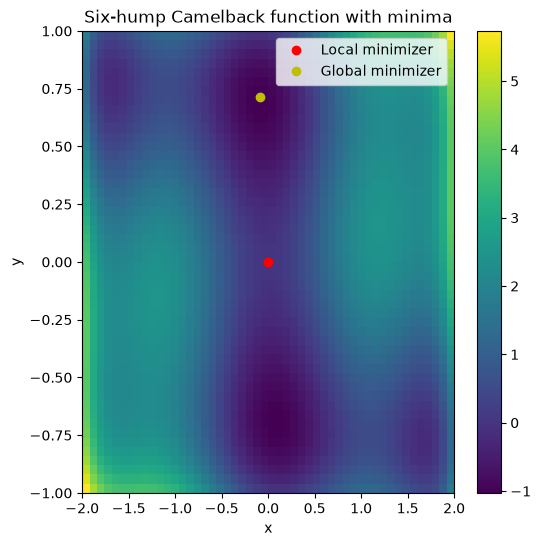

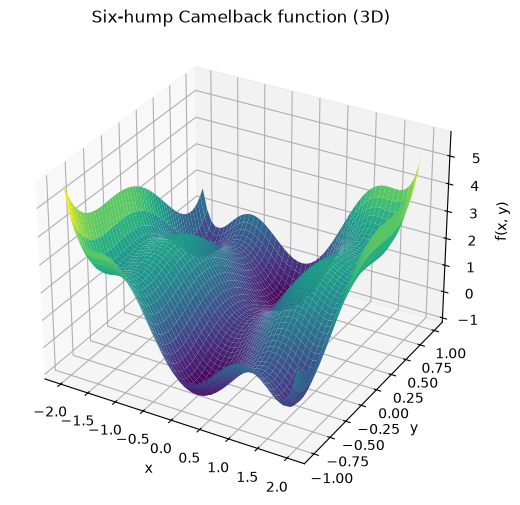

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

"""
Evaluate the Six-Hump Camelback function, locate its critical points using
numerical optimization, and generate both 2D and 3D visualizations.

Inputs:
    initial_guesses: Dictionary containing the initial guesses used for
                     the optimization algorithm.

Output:
    A 2D heatmap and a 3D surface plot of the Six-Hump Camelback function,
    with the critical points highlighted on the 2D plot.
"""

# -----------------------------------------------------------------------------
# 1. Definition of the Six-Hump Camelback Function
# -----------------------------------------------------------------------------
def six_hump_camelback(p):
    """
    Compute the value of the Six-Hump Camelback function.

    Input:
        p: List or array containing the coordinates [x, y].

    Output:
        The value of the function evaluated at (x, y).
    """
    x, y = p
    return (4 - 2.1 * x**2 + (x**4) / 3) * x**2 + x * y + (4 * y**2 - 4) * y**2


# Generate the domain grid: -2 < x < 2 and -1 < y < 1
x_vals = np.linspace(-2, 2)
y_vals = np.linspace(-1, 1)
X, Y = np.meshgrid(x_vals, y_vals)

# Evaluate the function on the grid
Z = six_hump_camelback([X, Y])

# -----------------------------------------------------------------------------
# 2. Optimization to Locate Critical Points
# -----------------------------------------------------------------------------

# Initial guesses for the optimization procedure
initial_guesses = {
    "local_1": [1.7036, -0.7961],
    "local_2": [-1.7036, 0.7961],
    "global_1": [0.0898, -0.7126],
    "global_2": [-0.0898, 0.7126],
    "saddle": [0.0, 0.0],
}

# Dictionary to store the optimized critical points
opt_points = {}

# Perform the optimization from each initial guess
for name, loc in initial_guesses.items():
    res = minimize(six_hump_camelback, loc)
    opt_points[name] = res.x

# -----------------------------------------------------------------------------
# 3. 2D Plot Generation (EX_2.10.2D.png)
# -----------------------------------------------------------------------------

# Create the figure and axes
fig, ax = plt.subplots(figsize=(6, 6))

# Display the function as a heatmap
im = ax.imshow(
    Z,
    extent=[-2, 2, -1, 1],
    origin="lower",
    aspect="auto"
)

# Add a colorbar
fig.colorbar(im, ax=ax)

# Plot the saddle point
ax.plot(
    opt_points["saddle"][0],
    opt_points["saddle"][1],
    "ro",
    label="Local minimizer",
)

# Plot one of the global minima
ax.plot(
    opt_points["global_2"][0],
    opt_points["global_2"][1],
    "yo",
    label="Global minimizer",
)

# Set the title and axis labels
ax.set_title("Six-hump Camelback function with minima")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Set the axis limits
ax.set_xlim(-2, 2)
ax.set_ylim(-1, 1)

# Display the legend
ax.legend(loc="upper right")

# Display the figure
plt.show()

# Save the figure
plt.savefig("EX_2.10.2D.png", dpi=300)

plt.close()

# -----------------------------------------------------------------------------
# 4. 3D Surface Plot Generation (EX_2.10.png)
# -----------------------------------------------------------------------------

# Create the figure and 3D axes
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(projection="3d")

# Display the function as a 3D surface
surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis"
)

# Set the title and axis labels
ax.set_title("Six-hump Camelback function (3D)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")

# Display the figure
plt.show()

# Save the figure
plt.savefig("EX_2.10.png", dpi=300)

plt.close()